In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ciochdawid/dailydelhiclimatetrain-csv",
    "DailyDelhiClimateTrain.csv"
)

# Display first 5 rows
print(df.head())

C:\Users\gaura\AppData\Local\Temp\ipykernel_27424\3471315634.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 76.4k/76.4k [00:00<00:00, 90.4kB/s]

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [3]:
data = df[['meantemp']]

In [4]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [5]:
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [7]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

e:\Anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0337 - val_loss: 0.0065
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069 - val_loss: 0.0052
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056 - val_loss: 0.0046
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - val_loss: 0.0064
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0060
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0042
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [10]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Reverse scaling
train_predict = scaler.inverse_transform(train_predict.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict.reshape(-1,1))

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


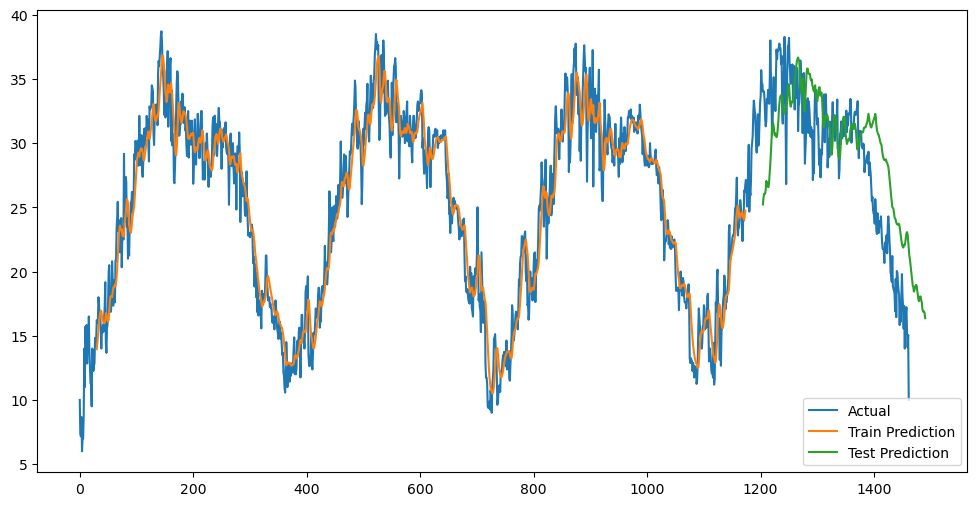

In [11]:
plt.figure(figsize=(12,6))

plt.plot(scaler.inverse_transform(scaled_data), label='Actual')
plt.plot(range(time_step, len(train_predict)+time_step), train_predict, label='Train Prediction')
plt.plot(range(len(train_predict)+(time_step*2), len(train_predict)+(time_step*2)+len(test_predict)), test_predict, label='Test Prediction')

plt.legend()
plt.show()

In [12]:
future_days = 7
temp_input = scaled_data[-time_step:].reshape(1, -1)

future_output = []

for i in range(future_days):
    temp_input_reshaped = temp_input.reshape(1, time_step, 1)
    pred = model.predict(temp_input_reshaped)

    future_output.append(pred[0][0])
    temp_input = np.append(temp_input[:,1:], pred, axis=1)

# Convert back to original scale
future_output = scaler.inverse_transform(np.array(future_output).reshape(-1,1))

print(future_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[15.229066]
 [14.896247]
 [14.761256]
 [14.730003]
 [14.753583]
 [14.806163]
 [14.87374 ]]
